**Feature Engineering – NBA Player Longevity Prediction**

Project Overview
In this project, you will analyze an NBA player performance dataset using Python and pandas to engineer features for a machine learning model. You will learn how to define target variables, remove noise, analyze correlations, create composite metrics, and clean data to build a robust predictive dataset. This project strengthens your ability to transform raw sports statistics into model-ready inputs for longevity forecasting.

**Step-by-Step Project Tasks**

- Load the dataset and clearly define the `target_5yrs` column as the dependent variable
- Drop non-predictive columns (e.g., player names, IDs) that add noise or risk data leakage
- Perform correlation analysis to identify highly correlated features and reduce redundancy
- Engineer at least one new composite feature (e.g., Points Per Minute, Efficiency Rating) by combining existing metrics
- Clean the dataset by handling null values in performance columns to ensure ML-readiness
- Document your feature selection and engineering choices with clear Markdown explanations

**Project Goal**

By the end of this project, your feature engineering pipeline should:
- Successfully isolate and format the `target_5yrs` variable for modeling
- Produce a clean, reduced dataset with irrelevant or redundant columns removed
- Identify and resolve multicollinearity among predictors using correlation analysis
- Introduce at least one meaningful derived metric that captures player efficiency or impact
- Handle missing values appropriately without introducing bias or data leakage
- Clearly justify all feature engineering decisions for model transparency and reproducibility

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading data
nba = pd.read_csv('Nba.csv')
nba.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


## **Data Exploration**

In [3]:
# Checking the shape of the dataset
nba.shape

(1340, 22)

In [4]:
# Checking for missing values
nba.isna().sum()

Unnamed: 0     0
name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

The dataset does not contain any missing values that need to be filled

In [5]:
# Checking for duplicates
nba.duplicated().sum()

np.int64(0)

The dataset does not contain duplicate values that need to be removed

### Dropping Non-Predictive Columns
The columns 'name' and 'Unnamed: 0' were removed because they do not contribute to prediction and may introduce noise or data leakage.

In [6]:
# Dropping non-predictive columns
nba = nba.drop(['Unnamed: 0','name'], axis=1)
nba.head(2)

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0


In [7]:
# Defining dependent and independent variables
x = nba.drop('target_5yrs',axis=1)
y = nba['target_5yrs']

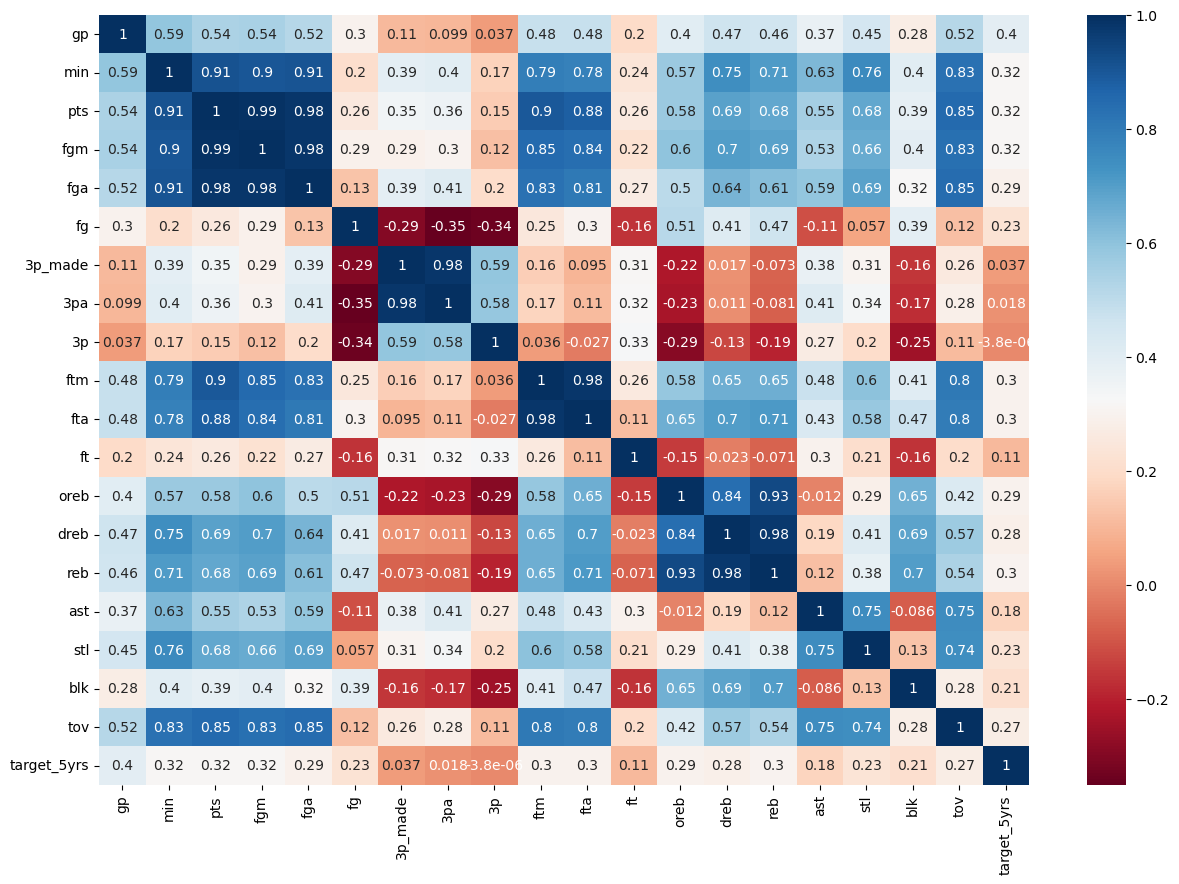

In [14]:
# Correlation analysis
corr = nba.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr,cmap='RdBu',annot=True)
plt.show()

### Handling Multicollinearity
Highly correlated features (r > 0.85) were removed to reduce redundancy and improve model stability.

In [9]:
# Filtering highly correlated features
threshold = 0.85
to_drop = set()

# Loop through the matrix to find highly correlated pairs
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col_i = corr.columns[i]
            col_j = corr.columns[j]
            
            # Skip if either column is the target itself
            if col_i == 'target_5yrs' or col_j == 'target_5yrs':
                continue
                
            # Compare their correlation with the target variable
            target_corr_i = abs(corr.loc[col_i, 'target_5yrs'])
            target_corr_j = abs(corr.loc[col_j, 'target_5yrs'])
            
            # Drop the one with the weaker relationship to the target
            if target_corr_i < target_corr_j:
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)

nba_reduced = nba.drop(columns=list(to_drop))
nba_reduced.head()

,gp,min,fg,3p_made,3p,ft,reb,ast,stl,blk,target_5yrs
0,36,27.4,34.7,0.5,25.0,69.9,4.1,1.9,0.4,0.4,0
1,35,26.9,29.6,0.7,23.5,76.5,2.4,3.7,1.1,0.5,0
2,74,15.3,42.2,0.4,24.4,67.0,2.2,1.0,0.5,0.3,0
3,58,11.6,42.6,0.1,22.6,68.9,1.9,0.8,0.6,0.1,1
4,48,11.5,52.4,0.0,0.0,67.4,2.5,0.3,0.3,0.4,1


### Feature Engineering
New feature, points per minute was created to better capture player performance beyond raw statistics.

In [10]:
# Feature Engineering
nba_reduced['pts_min'] = np.where(
    nba_reduced['min'] == 0, 
    0, 
    nba['pts'] / nba_reduced['min']
)
nba_reduced.head()

,gp,min,fg,3p_made,3p,ft,reb,ast,stl,blk,target_5yrs,pts_min
0,36,27.4,34.7,0.5,25.0,69.9,4.1,1.9,0.4,0.4,0,0.270073
1,35,26.9,29.6,0.7,23.5,76.5,2.4,3.7,1.1,0.5,0,0.267658
2,74,15.3,42.2,0.4,24.4,67.0,2.2,1.0,0.5,0.3,0,0.339869
3,58,11.6,42.6,0.1,22.6,68.9,1.9,0.8,0.6,0.1,1,0.491379
4,48,11.5,52.4,0.0,0.0,67.4,2.5,0.3,0.3,0.4,1,0.391304


In [12]:
# checking for missing values
nba_reduced.isna().sum()

gp             0
min            0
fg             0
3p_made        0
3p             0
ft             0
reb            0
ast            0
stl            0
blk            0
target_5yrs    0
pts_min        0
dtype: int64

The dataset does not contain any missing values that need to be filled

In [13]:
# Newly defined dependent and independent variables
X = nba_reduced.drop('target_5yrs', axis=1)
Y = nba_reduced['target_5yrs']